On Movies dataset:

Perform following operations;

1. Find the percentage of Missing values in each column.
2. For Columns, "country"and "rating", Replace the Missing value with Most probable value.
3. For "Date_Added" column, Replace NaN with any date in the "Release year" . if Release Year is also  NaN, then drop the row.
4. From Date_Added, Create new columns 'Year_Added' and'Month _Added'.
5. Discretize Rating column into three values only ("Kid", "teen" , "Adult").
6. Plot the number of movies in each rating group by each country.
7. Change the Listed-In column to single valued column by creating multiple columns foe each unique value in that column.
8. Drop all the columns with large number of distinct values and label encode rest of the columns.
9. perform correlation analysis on the rest of the labels.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
import seaborn as sns

In [2]:
df = pd.read_csv("../../datasets/Movies.csv", encoding="latin-1")

In [3]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,TV Show,3%,NaN,"JoÃ£o Miguel, Bianca Comparato, Michel Gomes, ...",Brazil,"August 14, 2020",2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s2,Movie,7:19,Jorge Michel Grau,"DemiÃ¡n Bichir, HÃ©ctor Bonilla, Oscar Serrano...",Mexico,"December 23, 2016",2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow..."
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",2009,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi..."
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",2008,PG-13,123 min,Dramas,A brilliant group of students become card-coun...


In [4]:
df.isnull().sum() / len(df) * 100

show_id          0.000000
type             0.000000
title            0.000000
director        30.679337
cast             9.220496
country          6.510851
date_added       0.128419
release_year     0.000000
rating           0.089893
duration         0.000000
listed_in        0.000000
description      0.000000
dtype: float64

In [5]:
df.fillna(
    {"country": df["country"].mode()[0], "rating": df["rating"].mode()[0]}, inplace=True
)
df.isnull().sum() / len(df) * 100

show_id          0.000000
type             0.000000
title            0.000000
director        30.679337
cast             9.220496
country          0.000000
date_added       0.128419
release_year     0.000000
rating           0.000000
duration         0.000000
listed_in        0.000000
description      0.000000
dtype: float64

In [6]:
df["date_added"] = pd.to_datetime(df["date_added"], errors="coerce")

mask = df["date_added"].isna() & df["release_year"].notna()
df.loc[mask, "date_added"] = pd.to_datetime(
    df.loc[mask, "release_year"].astype(str) + "-01-01"
)

df = df[~(df["date_added"].isna() & df["release_year"].isna())]

df.isnull().sum() / len(df) * 100

show_id          0.000000
type             0.000000
title            0.000000
director        30.679337
cast             9.220496
country          0.000000
date_added       0.000000
release_year     0.000000
rating           0.000000
duration         0.000000
listed_in        0.000000
description      0.000000
dtype: float64

In [7]:
df["Year_Added"] = df["date_added"].dt.year
df["Month_Added"] = df["date_added"].dt.month
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,Year_Added,Month_Added
0,s1,TV Show,3%,NaN,"JoÃ£o Miguel, Bianca Comparato, Michel Gomes, ...",Brazil,2020-08-14,2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...,2020,8
1,s2,Movie,7:19,Jorge Michel Grau,"DemiÃ¡n Bichir, HÃ©ctor Bonilla, Oscar Serrano...",Mexico,2016-12-23,2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...,2016,12
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,2018-12-20,2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow...",2018,12
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,2017-11-16,2009,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi...",2017,11
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,2020-01-01,2008,PG-13,123 min,Dramas,A brilliant group of students become card-coun...,2020,1


In [8]:
rating_to_age = {
    "": 0,
    "G": 0,
    "TV-G": 0,
    "TV-Y": 0,
    "TV-Y7": 7,
    "TV-Y7-FV": 7,
    "PG": 10,
    "TV-PG": 10,
    "PG-13": 13,
    "TV-14": 14,
    "R": 17,
    "NC-17": 18,
    "TV-MA": 17,
    "NR": 0,
    "UR": 0,
}


def map_rating_group(r):
    age = rating_to_age.get(str(r).strip(), np.nan)

    if pd.isna(age):
        return np.nan
    elif age <= 7:
        return "Kid"
    elif age <= 14:
        return "Teen"
    else:
        return "Adult"


df["rating"] = df["rating"].apply(map_rating_group)
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,Year_Added,Month_Added
0,s1,TV Show,3%,NaN,"JoÃ£o Miguel, Bianca Comparato, Michel Gomes, ...",Brazil,2020-08-14,2020,Adult,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...,2020,8
1,s2,Movie,7:19,Jorge Michel Grau,"DemiÃ¡n Bichir, HÃ©ctor Bonilla, Oscar Serrano...",Mexico,2016-12-23,2016,Adult,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...,2016,12
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,2018-12-20,2011,Adult,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow...",2018,12
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,2017-11-16,2009,Teen,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi...",2017,11
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,2020-01-01,2008,Teen,123 min,Dramas,A brilliant group of students become card-coun...,2020,1


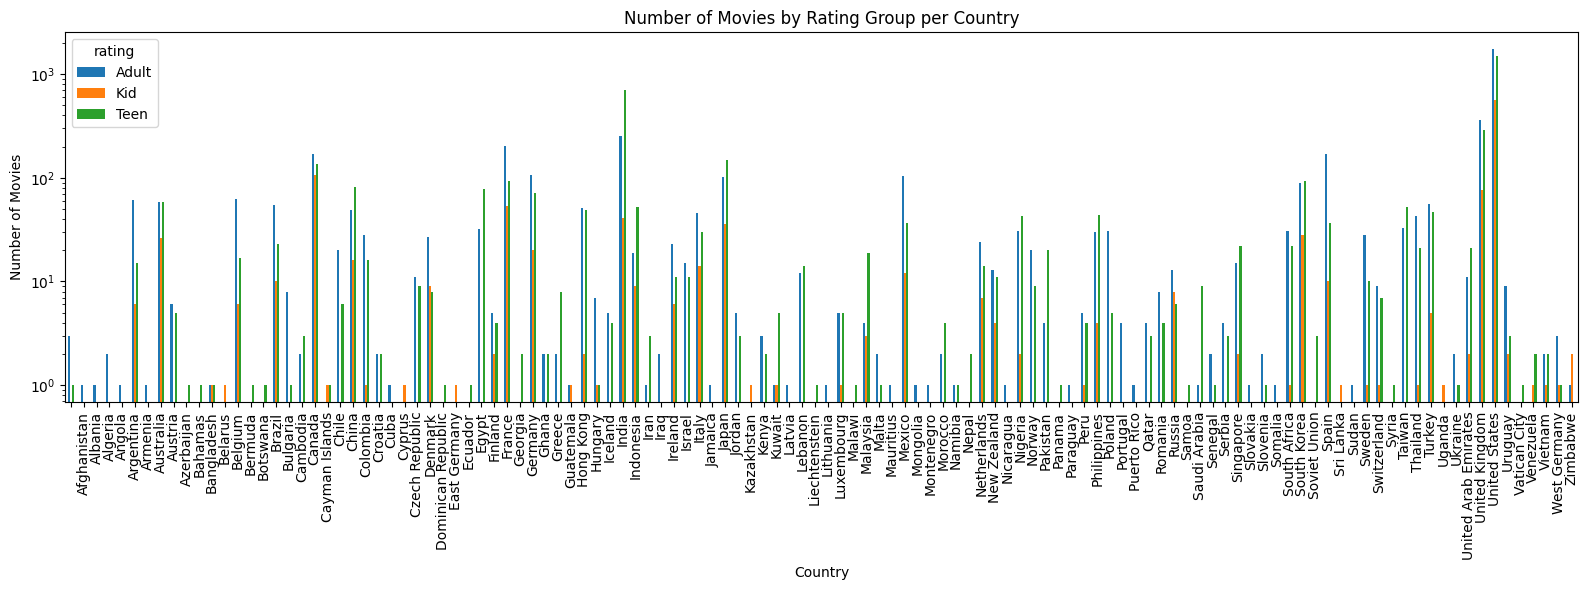

In [9]:
df["country_list"] = df["country"].str.split(",")
# This gives each country in list 1 row each
df = df.explode("country_list")
df["country_list"] = df["country_list"].str.strip()
counts = df.groupby(["country_list", "rating"]).size().unstack(fill_value=0)

counts.plot(kind="bar", figsize=(16, 6))

plt.xlabel("Country")
plt.ylabel("Number of Movies")
plt.title("Number of Movies by Rating Group per Country")
plt.xticks(rotation=90)
plt.yscale("log")
plt.tight_layout()
plt.show()

In [10]:
# Split genres
df["listed_in"] = df["listed_in"].str.split(",")

df = df.explode("listed_in")
df["listed_in"] = df["listed_in"].str.strip()

dummies = pd.get_dummies(df["listed_in"], prefix="genre")

dummies.columns = dummies.columns.str.strip()

# Step 3: merge back (or replace original column)
df = pd.concat([df.drop(columns=["listed_in"]), dummies], axis=1)

In [11]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,...,genre_TV Action & Adventure,genre_TV Comedies,genre_TV Dramas,genre_TV Horror,genre_TV Mysteries,genre_TV Sci-Fi & Fantasy,genre_TV Shows,genre_TV Thrillers,genre_Teen TV Shows,genre_Thrillers
0,s1,TV Show,3%,NaN,"JoÃ£o Miguel, Bianca Comparato, Michel Gomes, ...",Brazil,2020-08-14,2020,Adult,4 Seasons,...,False,False,False,False,False,False,False,False,False,False
0,s1,TV Show,3%,NaN,"JoÃ£o Miguel, Bianca Comparato, Michel Gomes, ...",Brazil,2020-08-14,2020,Adult,4 Seasons,...,False,False,True,False,False,False,False,False,False,False
0,s1,TV Show,3%,NaN,"JoÃ£o Miguel, Bianca Comparato, Michel Gomes, ...",Brazil,2020-08-14,2020,Adult,4 Seasons,...,False,False,False,False,False,True,False,False,False,False
1,s2,Movie,7:19,Jorge Michel Grau,"DemiÃ¡n Bichir, HÃ©ctor Bonilla, Oscar Serrano...",Mexico,2016-12-23,2016,Adult,93 min,...,False,False,False,False,False,False,False,False,False,False
1,s2,Movie,7:19,Jorge Michel Grau,"DemiÃ¡n Bichir, HÃ©ctor Bonilla, Oscar Serrano...",Mexico,2016-12-23,2016,Adult,93 min,...,False,False,False,False,False,False,False,False,False,False


In [12]:
cat_cols = df.columns
unique_counts = df[cat_cols].nunique()

high_card_cols = unique_counts[unique_counts > 500].index
df = df.drop(columns=high_card_cols)
cat_cols = df.columns

label_encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

In [13]:
df.head()

,type,release_year,rating,duration,Year_Added,Month_Added,country_list,genre_Action & Adventure,genre_Anime Features,genre_Anime Series,...,genre_TV Action & Adventure,genre_TV Comedies,genre_TV Dramas,genre_TV Horror,genre_TV Mysteries,genre_TV Sci-Fi & Fantasy,genre_TV Shows,genre_TV Thrillers,genre_Teen TV Shows,genre_Thrillers
0,1,71,0,147,20,10,16,0,0,0,...,0,0,0,0,0,0,0,0,0,0
0,1,71,0,147,20,10,16,0,0,0,...,0,0,1,0,0,0,0,0,0,0
0,1,71,0,147,20,10,16,0,0,0,...,0,0,0,0,0,1,0,0,0,0
1,0,67,0,209,16,3,65,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,67,0,209,16,3,65,0,0,0,...,0,0,0,0,0,0,0,0,0,0


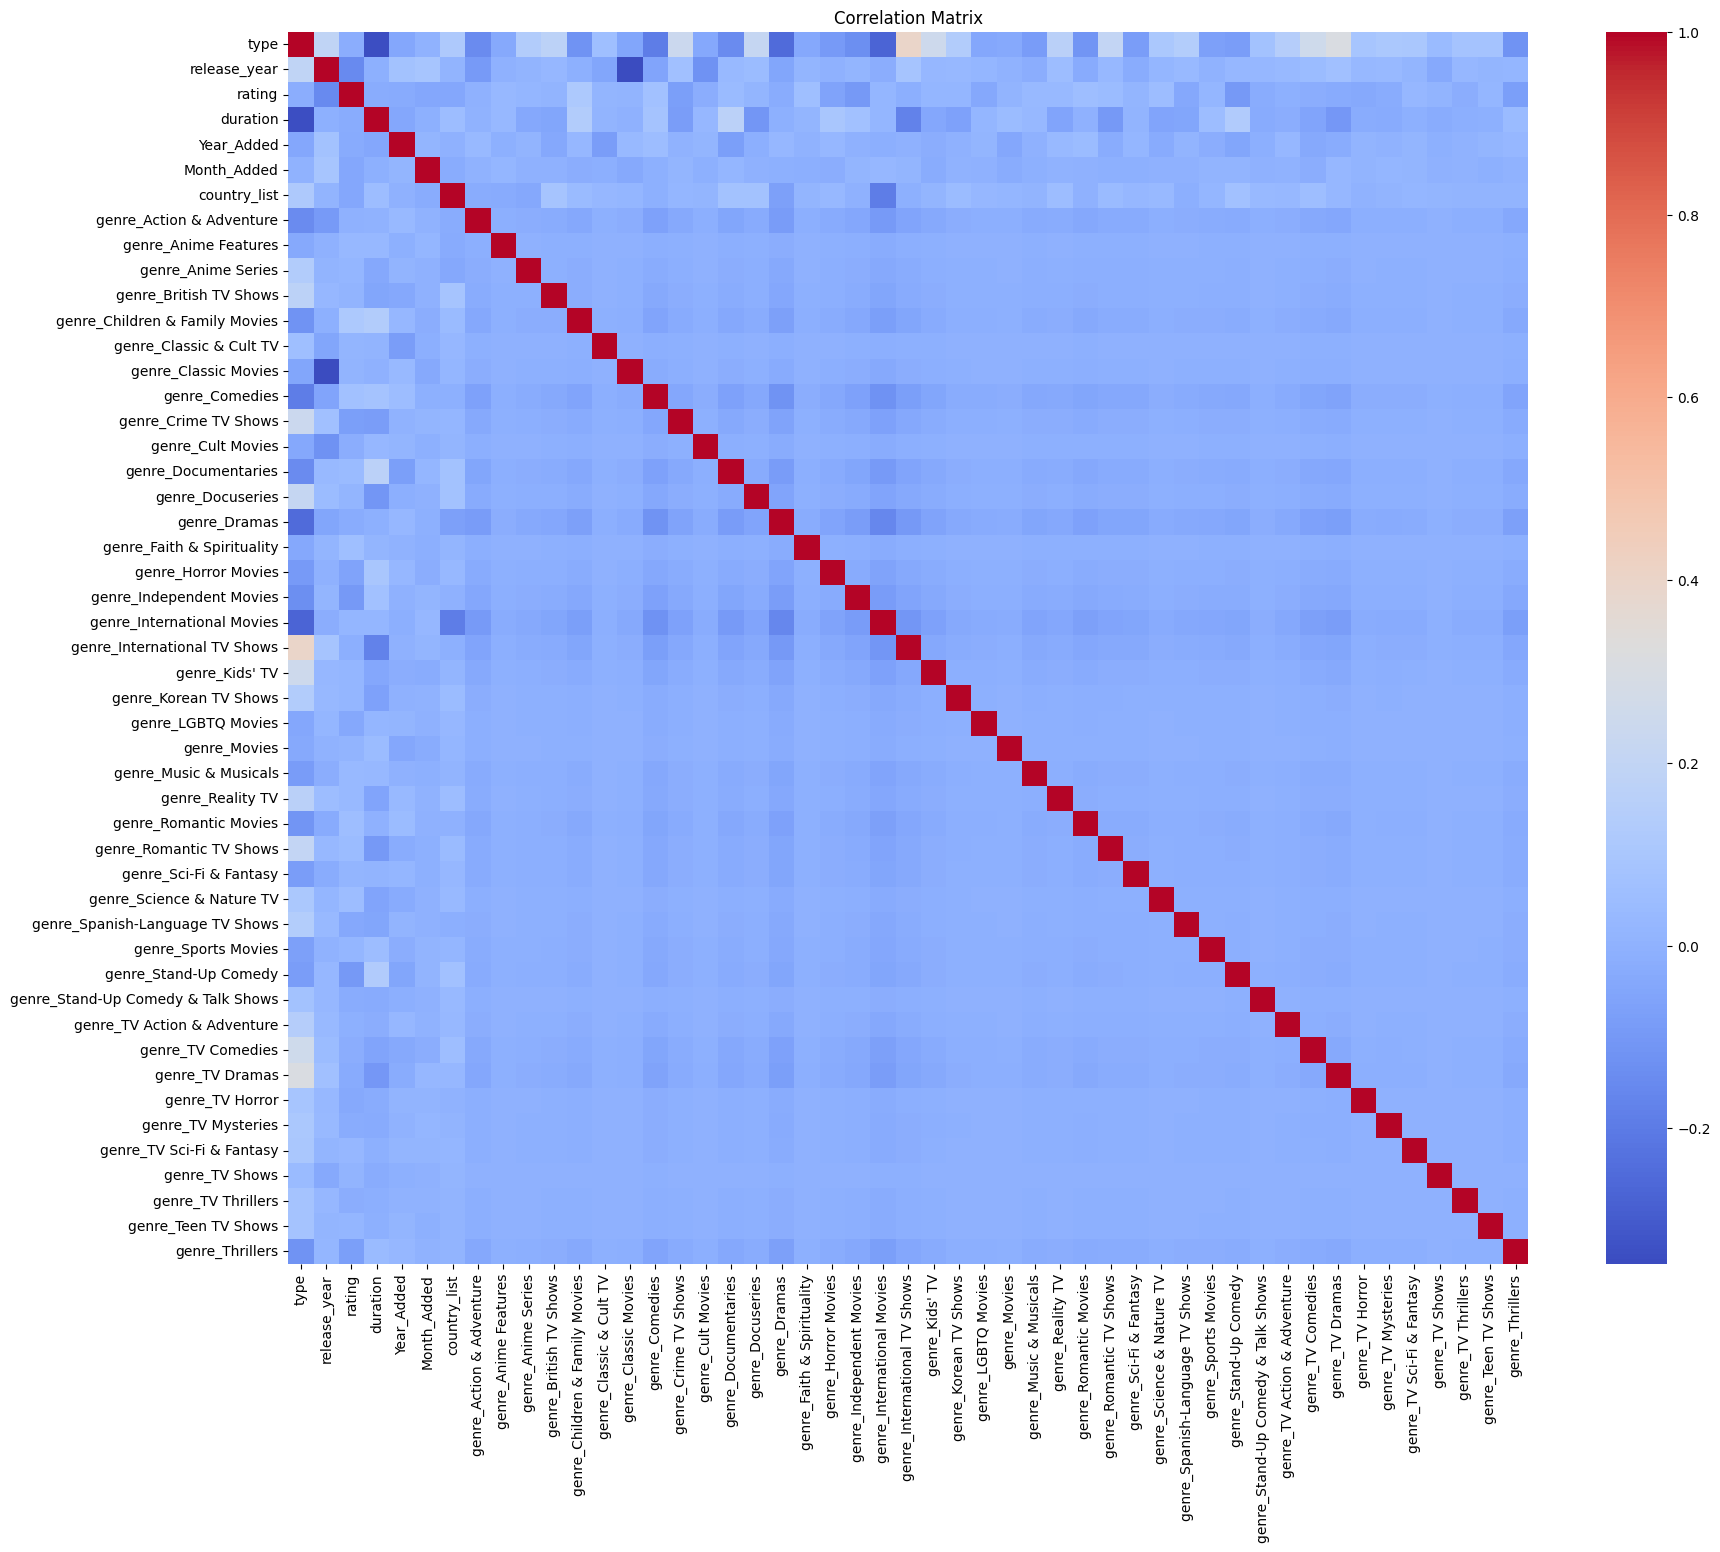

In [14]:
corr = df.corr()

plt.figure(figsize=(20, 16))
sns.heatmap(corr, annot=False, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()